# **Licenciatura em Ciências da Computação**

### Aprendizagem Computacional 25/26

# Spam Detection with Text Data — Complete ML Pipeline
End-to-end machine learning workflow for spam detection using a public SMS dataset.

Topics Adressed:
*   Text Processing
*   Feature Extraction/Engineering
*   Feature Selection
*   Stratified Cross-validation
*   Hold-out Test Set Evaluation








## 0. Imports

In [1]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

from scipy.stats import ttest_rel


## 1. Load SMS Spam Dataset

In [2]:
import requests
import zipfile
import io

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
response = requests.get(url)
zip_file = zipfile.ZipFile(io.BytesIO(response.content))

with zip_file.open("SMSSpamCollection") as f:
    df = pd.read_csv(f, sep="\t", header=None,
                      names=["label","text"], encoding="utf-8")

df["label"] = df["label"].astype(str).str.lower()

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 2. Dataset Exploration

Example message
Label: ham
Text : Squeeeeeze!! This is christmas hug.. If u lik my frndshp den hug me back.. If u get 3 u r cute:) 6 u r luvd:* 9 u r so lucky;) None? People hate u: 

Dataset shape: (5572, 2)

Class distribution
label
ham     4825
spam     747
Name: count, dtype: int64


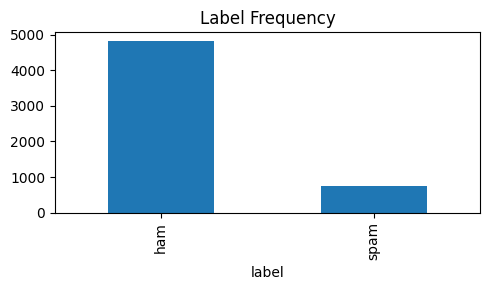

In [6]:
row = df.sample(1, random_state=42).iloc[0]
print("Example message")
print("Label:", row["label"])
print("Text :", row["text"], "\n")

print("Dataset shape:", df.shape)

label_counts = df["label"].value_counts()
print("\nClass distribution")
print(label_counts)

plt.figure(figsize=(5,3))
label_counts.plot(kind="bar")
plt.title("Label Frequency")
plt.tight_layout()
plt.show()


## 3. Train/Test Split

To ensure our model can generalize well to unseen data, we'll split the dataset into training and testing sets. The training set will be used to train the machine learning model, and the testing set will be used to evaluate its performance.

In [7]:
X = df["text"].astype(str)
y = df["label"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train size:", len(X_train))
print("Test size :", len(X_test))

Train size: 4457
Test size : 1115


# Text Preprocessing
Define the `simple_clean` function that converts text to lowercase and standardizes whitespace, preserving punctuation and digits. Then apply this function to `X_train` to create `X_train_cleaned`.

In [8]:
def simple_clean(text):
    # Convert to lowercase
    text = text.lower()
    # Standardize whitespace (replace multiple whitespaces with a single space)
    text = re.sub(r'\s+', ' ', text).strip()
    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # remove digits
    text = re.sub(r'\d+', '', text)
    return text

In [9]:
X_train_cleaned = X_train.apply(simple_clean)
print("First 5 entries of X_train_cleaned:")
print(X_train_cleaned.head())

First 5 entries of X_train_cleaned:
184                                he will you guys close
2171    can i please come up now imin towndontmatter i...
5422                     ok ksry i knw  sivatats y i askd
4113                              ill see but prolly yeah
4588    ill see if i can swing by in a bit got some th...
Name: text, dtype: str


In [10]:
print(f"'{X_train_cleaned.iloc[0]}'")

'he will you guys close'


## Feature Extraction/Engineering

In [11]:
def manual_features(text):
    features = {}

    # 2. Calculate message_length
    features['message_length'] = len(text)

    # 3. Calculate num_digits
    features['num_digits'] = sum(c.isdigit() for c in text)

    # 4. Calculate num_exclamation_marks
    features['num_exclamation_marks'] = text.count('!')

    # 5. Calculate uppercase_ratio
    num_uppercase = sum(c.isupper() for c in text)
    if features['message_length'] > 0:
        features['uppercase_ratio'] = num_uppercase / features['message_length']
    else:
        features['uppercase_ratio'] = 0

    # 6. Define spam_keywords
    spam_keywords = ['free', 'win', 'urgent', 'call', 'cash', 'prize', 'txt', 'mobile', 'stop', 'claim']

    # 7. Convert text to lowercase for case-insensitive keyword counting
    text_lower = text.lower()

    # 8. Count occurrences of spam-related keywords
    for keyword in spam_keywords:
        features[f'keyword_count_{keyword}'] = text_lower.count(keyword)

    return features

In [12]:
X_train_manual_features = pd.DataFrame(X_train.apply(manual_features).tolist())
print("First 5 entries of X_train_manual_features:")
print(X_train_manual_features.head())

First 5 entries of X_train_manual_features:
   message_length  num_digits  num_exclamation_marks  uppercase_ratio  \
0              24           0                      0         0.041667   
1             159           4                      0         0.811321   
2              39           1                      0         0.025641   
3              25           0                      0         0.040000   
4              79           0                      0         0.025316   

   keyword_count_free  keyword_count_win  keyword_count_urgent  \
0                   0                  0                     0   
1                   0                  0                     0   
2                   0                  0                     0   
3                   0                  0                     0   
4                   0                  1                     0   

   keyword_count_call  keyword_count_cash  keyword_count_prize  \
0                   0                   0             

## Text Vectorization (Bag-of-Words) on Cleaned Training Data

Use `CountVectorizer` to convert the `X_train_cleaned` text into a numerical Bag-of-Words representation.


In [13]:
vectorizer = CountVectorizer()
X_train_bow = vectorizer.fit_transform(X_train_cleaned)

# Convert the sparse matrix to a DataFrame for easier inspection
X_train_bow_df = pd.DataFrame(
    X_train_bow.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=X_train_cleaned.index
)

print("First 5 entries of X_train_bow_df:")
print(X_train_bow_df.head())

First 5 entries of X_train_bow_df:
      aa  aah  aaniye  aathilove  aathiwhere  ab  abbey  abdomen  abeg  abelu  \
184    0    0       0          0           0   0      0        0     0      0   
2171   0    0       0          0           0   0      0        0     0      0   
5422   0    0       0          0           0   0      0        0     0      0   
4113   0    0       0          0           0   0      0        0     0      0   
4588   0    0       0          0           0   0      0        0     0      0   

      ...  zealand  zed  zeros  zhong  zindgi  zoe  zogtorius  zyada  üll  〨ud  
184   ...        0    0      0      0       0    0          0      0    0    0  
2171  ...        0    0      0      0       0    0          0      0    0    0  
5422  ...        0    0      0      0       0    0          0      0    0    0  
4113  ...        0    0      0      0       0    0          0      0    0    0  
4588  ...        0    0      0      0       0    0          0      0    0

## Combine All Features for Training

Combine the manually engineered features (from the original `X_train`) and the Bag-of-Words features (from `X_train_cleaned`) into a single feature matrix that will be used for model training.


In [14]:
X_train_manual_features = X_train.apply(manual_features).apply(pd.Series)

X_train_combined = pd.concat([X_train_manual_features, X_train_bow_df], axis=1)

print("Shape of X_train_combined:", X_train_combined.shape)
print("\nFirst 5 entries of X_train_combined:")
print(X_train_combined.head())

Shape of X_train_combined: (4457, 7551)

First 5 entries of X_train_combined:
      message_length  num_digits  num_exclamation_marks  uppercase_ratio  \
184             24.0         0.0                    0.0         0.041667   
2171           159.0         4.0                    0.0         0.811321   
5422            39.0         1.0                    0.0         0.025641   
4113            25.0         0.0                    0.0         0.040000   
4588            79.0         0.0                    0.0         0.025316   

      keyword_count_free  keyword_count_win  keyword_count_urgent  \
184                  0.0                0.0                   0.0   
2171                 0.0                0.0                   0.0   
5422                 0.0                0.0                   0.0   
4113                 0.0                0.0                   0.0   
4588                 0.0                1.0                   0.0   

      keyword_count_call  keyword_count_cash  keyw

## Feature Selection

### What is Feature Selection?

Feature selection is a crucial step in the machine learning pipeline that involves choosing a subset of relevant features (variables, predictors) from the original set to use in model construction. The main goals of feature selection are:

1.  **Dimensionality Reduction:** Reducing the number of input variables makes the model simpler and faster to train.
2.  **Improved Model Performance:** By removing irrelevant or redundant features, models can often achieve better accuracy and generalization, as they are less prone to overfitting.
3.  **Enhanced Interpretability:** A model built with fewer, more relevant features is often easier to understand and interpret.
4.  **Reduced Training Time and Cost:** Fewer features mean less data to process, leading to faster training and inference.

### How `SelectKBest` Works

`SelectKBest` is a feature selection method provided by scikit-learn that selects the *k* top features based on a scoring function. It works by calculating a score for each feature independently with respect to the target variable and then picking the features with the highest scores. The choice of scoring function depends on the type of data (numerical or categorical) and the problem type (classification or regression).

### Chi-squared Test (`chi2`) for Text Classification

For text classification problems, where features often represent word frequencies (e.g., Bag-of-Words) and the target variable is categorical (e.g., 'spam' or 'ham'), the **Chi-squared statistical test (`chi2`)** is a highly suitable scoring function for `SelectKBest`.

Here's why `chi2` is effective for text data:

*   **Measures Dependence:** The Chi-squared test measures the independence between categorical variables. In text classification, it assesses whether the presence (or frequency) of a particular word (feature) is independent of the class label (target variable). A high chi-squared score indicates that the feature is highly dependent on the class label, making it a strong predictor.
*   **Identifies Relevant Words:** It helps to identify words or terms that are significantly associated with a specific class. For instance, words that appear frequently in spam messages but rarely in ham messages will have a high chi-squared score for the 'spam' class.
*   **Non-negative Features:** Chi-squared is typically used with non-negative features, which is characteristic of text data representations like Bag-of-Words where feature values often represent counts.

By using `SelectKBest` with the `chi2` test, we can effectively identify and keep the most discriminative words or features from our text data. This reduces the feature space, mitigates the curse of dimensionality, and helps in building more robust and efficient text classification models.

## Apply Feature Selection

Apply `SelectKBest` with `chi2` to `X_train_combined` to select approximately 75% of the features. Calculate `k` based on the total number of features in `X_train_combined`. This will create a reduced feature set, `X_train_selected`.


In [15]:
k_features = int(0.75 * X_train_combined.shape[1])

selector = SelectKBest(chi2, k=k_features)
selector.fit(X_train_combined, y_train)

X_train_selected = selector.transform(X_train_combined)

selected_features = X_train_combined.columns[selector.get_support(indices=True)]
X_train_selected = pd.DataFrame(
    X_train_selected,
    columns=selected_features,
    index=X_train_combined.index
)

print(f"Original number of features: {X_train_combined.shape[1]}")
print(f"Number of features selected (k): {k_features}")
print(f"Shape of X_train_selected: {X_train_selected.shape}")
print("\nFirst 5 entries of X_train_selected:")
print(X_train_selected.head())

Original number of features: 7551
Number of features selected (k): 5663
Shape of X_train_selected: (4457, 5663)

First 5 entries of X_train_selected:
      message_length  num_digits  num_exclamation_marks  uppercase_ratio  \
184             24.0         0.0                    0.0         0.041667   
2171           159.0         4.0                    0.0         0.811321   
5422            39.0         1.0                    0.0         0.025641   
4113            25.0         0.0                    0.0         0.040000   
4588            79.0         0.0                    0.0         0.025316   

      keyword_count_free  keyword_count_win  keyword_count_urgent  \
184                  0.0                0.0                   0.0   
2171                 0.0                0.0                   0.0   
5422                 0.0                0.0                   0.0   
4113                 0.0                0.0                   0.0   
4588                 0.0                1.0     

## Set Up Cross-Validation and Evaluation Metric

Define the `StratifiedKFold` cross-validation strategy for consistent splits and create a helper function `f1_spam` to calculate the F1-score specifically for the 'spam' class, as this is a key metric for imbalanced classification problems like spam detection.


In [16]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def f1_spam(y_true, y_pred):
    return f1_score(y_true, y_pred, pos_label='spam', average='binary')

## Cross-Validation for Multinomial Naive Bayes

Implement a cross-validation loop to train and evaluate a `MultinomialNB` classifier. Collect the F1-scores for the 'spam' class from each fold and report the mean and standard deviation of these scores.


In [17]:
mnb_f1_scores = []
mnb = MultinomialNB()

# Reset index of X_train_selected and y_train to ensure correct slicing
# This is important if they lost their original index alignment during previous operations
X_train_selected_reset = X_train_selected.reset_index(drop=True)
y_train_reset = y_train.reset_index(drop=True)

for train_index, val_index in skf.split(X_train_selected_reset, y_train_reset):
    X_train_fold, X_val_fold = X_train_selected_reset.iloc[train_index], X_train_selected_reset.iloc[val_index]
    y_train_fold, y_val_fold = y_train_reset.iloc[train_index], y_train_reset.iloc[val_index]

    mnb.fit(X_train_fold, y_train_fold)
    y_pred_mnb = mnb.predict(X_val_fold)

    score = f1_spam(y_val_fold, y_pred_mnb)
    mnb_f1_scores.append(score)

print(f"MultinomialNB CV F1-score (spam) Mean: {np.mean(mnb_f1_scores):.4f}")
print(f"MultinomialNB CV F1-score (spam) Std:  {np.std(mnb_f1_scores):.4f}")

MultinomialNB CV F1-score (spam) Mean: 0.9457
MultinomialNB CV F1-score (spam) Std:  0.0092


## Cross-Validation for K-Nearest Neighbors (KNN)

In [18]:
knn_f1_scores = []
knn = KNeighborsClassifier(n_neighbors=5)


for train_index, val_index in skf.split(X_train_selected_reset, y_train_reset):
    X_train_fold, X_val_fold = X_train_selected_reset.iloc[train_index], X_train_selected_reset.iloc[val_index]
    y_train_fold, y_val_fold = y_train_reset.iloc[train_index], y_train_reset.iloc[val_index]

    knn.fit(X_train_fold, y_train_fold)
    y_pred_knn = knn.predict(X_val_fold)

    score = f1_spam(y_val_fold, y_pred_knn)
    knn_f1_scores.append(score)

print(f"KNeighborsClassifier CV F1-score (spam) Mean: {np.mean(knn_f1_scores):.4f}")
print(f"KNeighborsClassifier CV F1-score (spam) Std:  {np.std(knn_f1_scores):.4f}")

KNeighborsClassifier CV F1-score (spam) Mean: 0.9033
KNeighborsClassifier CV F1-score (spam) Std:  0.0089


## Compare Cross-Validation Results

In [19]:
print(f"Multinomial Naive Bayes (MNB) F1-score (spam) Mean: {np.mean(mnb_f1_scores):.4f}")
print(f"Multinomial Naive Bayes (MNB) F1-score (spam) Std:  {np.std(mnb_f1_scores):.4f}\n")

print(f"K-Nearest Neighbors (KNN) F1-score (spam) Mean: {np.mean(knn_f1_scores):.4f}")
print(f"K-Nearest Neighbors (KNN) F1-score (spam) Std:  {np.std(knn_f1_scores):.4f}")

Multinomial Naive Bayes (MNB) F1-score (spam) Mean: 0.9457
Multinomial Naive Bayes (MNB) F1-score (spam) Std:  0.0092

K-Nearest Neighbors (KNN) F1-score (spam) Mean: 0.9033
K-Nearest Neighbors (KNN) F1-score (spam) Std:  0.0089


In [20]:
print('NB ', mnb_f1_scores)
print('KNN ', knn_f1_scores)

NB  [0.9401709401709402, 0.9356223175965666, 0.9504132231404959, 0.940677966101695, 0.9613733905579399]
KNN  [0.8938053097345132, 0.9026548672566371, 0.8936170212765957, 0.9162995594713657, 0.9099099099099099]


## Perform Paired T-test on Cross-Validation Scores


In [21]:
t_statistic, p_value = ttest_rel(mnb_f1_scores, knn_f1_scores)

print(f"Paired t-test p-value:     {p_value:.4f}")

Paired t-test p-value:     0.0021


### Interpretation of Paired T-test Results

**P-value:** 0.0021

The paired t-test was performed to determine if there is a statistically significant difference between the F1-scores of the Multinomial Naive Bayes (MNB) and K-Nearest Neighbors (KNN) models, evaluated using cross-validation on the same folds.

**Statistical Significance:**
*   Since p < 0.05, we **reject the null hypothesis**. The null hypothesis states that there is no significant difference between the average F1-scores of the two models.
*   Therefore, we can conclude that there is a **statistically significant difference** in the F1-scores between the Multinomial Naive Bayes and K-Nearest Neighbors models.

Given the statistically significant difference and the much higher mean F1-score for the 'spam' class, the **Multinomial Naive Bayes model performed significantly better than the K-Nearest Neighbors model** for this spam detection task. This aligns with the expectation that Naive Bayes, particularly Multinomial Naive Bayes, often performs well on text classification problems, especially with Bag-of-Words features, due to its suitability for count data and its assumption of feature independence which can be reasonably met in text.

## Train Final Model (Multinomial Naive Bayes)

Based on the cross-validation results and the paired t-test, Multinomial Naive Bayes (`MultinomialNB`) significantly outperformed K-Nearest Neighbors for this spam detection task. We will now train the final `MultinomialNB` model using the entire `X_train_selected` dataset and `y_train`.

In [22]:
final_mnb_model = MultinomialNB()
final_mnb_model.fit(X_train_selected, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


________________________________________________________________________________________________________________________________________

# Prepare Test Data for Final Evaluation

Now that the final model (`final_mnb_model`) has been trained, we need to preprocess the test data (`X_test`) using the exact same steps and fitted transformers as were used for the training data. This ensures consistency and prevents data leakage.

## Prepare Test Data (Text Cleaning)

In [23]:
X_test_cleaned = X_test.apply(simple_clean)
print("First 5 entries of X_test_cleaned:")
print(X_test_cleaned.head())

First 5 entries of X_test_cleaned:
2825          no need to buy lunch for me i eat maggi mee
3695    ok im not sure what time i finish tomorrow but...
3904    waiting in e car  my mum lor u leh reach home ...
576          you have won  cash or a  prize to claim call
2899            if you r  home then come down within  min
Name: text, dtype: str


## Prepare Test Data (Manual Feature Extraction)


In [24]:
X_test_manual_features = pd.DataFrame(X_test.apply(manual_features).tolist())
print("First 5 entries of X_test_manual_features:")
print(X_test_manual_features.head())

First 5 entries of X_test_manual_features:
   message_length  num_digits  num_exclamation_marks  uppercase_ratio  \
0              47           0                      0         0.042553   
1             128           0                      1         0.015625   
2              57           1                      0         0.052632   
3              69          19                      1         0.028986   
4              43           1                      0         0.023256   

   keyword_count_free  keyword_count_win  keyword_count_urgent  \
0                   0                  0                     0   
1                   0                  0                     0   
2                   0                  0                     0   
3                   0                  0                     0   
4                   0                  0                     0   

   keyword_count_call  keyword_count_cash  keyword_count_prize  \
0                   0                   0              

## Prepare Test Data (Text Vectorization)

Apply the *fitted* `CountVectorizer` (`vectorizer`) to `X_test_cleaned` to transform it into a Bag-of-Words representation. Ensure the output is converted into a DataFrame named `X_test_bow_df` with appropriate column names and index, mirroring the `X_train_bow_df` structure.


In [25]:
X_test_bow = vectorizer.transform(X_test_cleaned)

X_test_bow_df = pd.DataFrame(
    X_test_bow.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=X_test_cleaned.index
)

print("First 5 entries of X_test_bow_df:")
print(X_test_bow_df.head())

First 5 entries of X_test_bow_df:
      aa  aah  aaniye  aathilove  aathiwhere  ab  abbey  abdomen  abeg  abelu  \
2825   0    0       0          0           0   0      0        0     0      0   
3695   0    0       0          0           0   0      0        0     0      0   
3904   0    0       0          0           0   0      0        0     0      0   
576    0    0       0          0           0   0      0        0     0      0   
2899   0    0       0          0           0   0      0        0     0      0   

      ...  zealand  zed  zeros  zhong  zindgi  zoe  zogtorius  zyada  üll  〨ud  
2825  ...        0    0      0      0       0    0          0      0    0    0  
3695  ...        0    0      0      0       0    0          0      0    0    0  
3904  ...        0    0      0      0       0    0          0      0    0    0  
576   ...        0    0      0      0       0    0          0      0    0    0  
2899  ...        0    0      0      0       0    0          0      0    0 

In [26]:
X_test_manual_features = X_test.apply(manual_features).apply(pd.Series)

X_test_combined = pd.concat([X_test_manual_features, X_test_bow_df], axis=1)

X_test_selected = selector.transform(X_test_combined)

# Ensure the output is a DataFrame with correct column names and index
X_test_selected = pd.DataFrame(
    X_test_selected,
    columns=selected_features,
    index=X_test_combined.index
)

print(f"Shape of X_test_selected: {X_test_selected.shape}")
print("\nFirst 5 entries of X_test_selected:")
print(X_test_selected.head())

Shape of X_test_selected: (1115, 5663)

First 5 entries of X_test_selected:
      message_length  num_digits  num_exclamation_marks  uppercase_ratio  \
2825            47.0         0.0                    0.0         0.042553   
3695           128.0         0.0                    1.0         0.015625   
3904            57.0         1.0                    0.0         0.052632   
576             69.0        19.0                    1.0         0.028986   
2899            43.0         1.0                    0.0         0.023256   

      keyword_count_free  keyword_count_win  keyword_count_urgent  \
2825                 0.0                0.0                   0.0   
3695                 0.0                0.0                   0.0   
3904                 0.0                0.0                   0.0   
576                  0.0                0.0                   0.0   
2899                 0.0                0.0                   0.0   

      keyword_count_call  keyword_count_cash  keywor

## Evaluate Final Model on Test Data

Use the `final_mnb_model` to make predictions on `X_test_selected` and evaluate its performance using the `f1_spam` metric, as well as other relevant classification metrics like accuracy, precision, and recall.


In [27]:
y_pred_test = final_mnb_model.predict(X_test_selected)

accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test, pos_label='spam', average='binary')
recall_test = recall_score(y_test, y_pred_test, pos_label='spam', average='binary')
f1_test = f1_spam(y_test, y_pred_test)

print(f"Accuracy on Test Set:  {accuracy_test:.4f}")
print(f"Precision on Test Set: {precision_test:.4f}")
print(f"Recall on Test Set:    {recall_test:.4f}")
print(f"F1-score (spam) on Test Set: {f1_test:.4f}")

Accuracy on Test Set:  0.9830
Precision on Test Set: 0.9643
Recall on Test Set:    0.9060
F1-score (spam) on Test Set: 0.9343


In [28]:
print("Classification Report on Test Set:")
print(classification_report(y_test, y_pred_test))

Classification Report on Test Set:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.91      0.93       149

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



<Figure size 600x500 with 0 Axes>

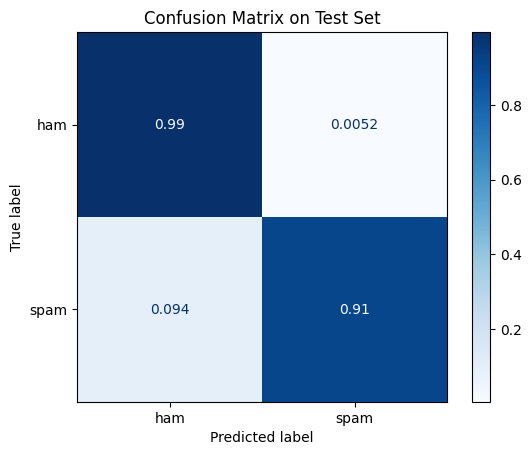

In [29]:
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, cmap='Blues', normalize='true')
plt.title('Confusion Matrix on Test Set')
plt.grid(False)
plt.show()